This question should be answered using the Weekly data set, which
is part of the ISLP package. This data is similar in nature to the
Smarket data from this chapter’s lab, except that it contains 1, 089
weekly returns for 21 years, from the beginning of 1990 to the end of
2010.

In [5]:
!pip install ISLP
from ISLP import load_data
weekly = load_data('Weekly')
weekly.head()


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=458d688893b1f7cfdd718ce248faa94ca3b3c2e982fa2ca831a191dd3822ab6d
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


(a) Produce some numerical and graphical summaries of the Weekly
data. Do there appear to be any patterns?

            Year      Lag1      Lag2      Lag3      Lag4      Lag5    Volume  \
Year    1.000000 -0.032289 -0.033390 -0.030006 -0.031128 -0.030519  0.841942   
Lag1   -0.032289  1.000000 -0.074853  0.058636 -0.071274 -0.008183 -0.064951   
Lag2   -0.033390 -0.074853  1.000000 -0.075721  0.058382 -0.072499 -0.085513   
Lag3   -0.030006  0.058636 -0.075721  1.000000 -0.075396  0.060657 -0.069288   
Lag4   -0.031128 -0.071274  0.058382 -0.075396  1.000000 -0.075675 -0.061075   
Lag5   -0.030519 -0.008183 -0.072499  0.060657 -0.075675  1.000000 -0.058517   
Volume  0.841942 -0.064951 -0.085513 -0.069288 -0.061075 -0.058517  1.000000   
Today  -0.032460 -0.075032  0.059167 -0.071244 -0.007826  0.011013 -0.033078   

           Today  
Year   -0.032460  
Lag1   -0.075032  
Lag2    0.059167  
Lag3   -0.071244  
Lag4   -0.007826  
Lag5    0.011013  
Volume -0.033078  
Today   1.000000  


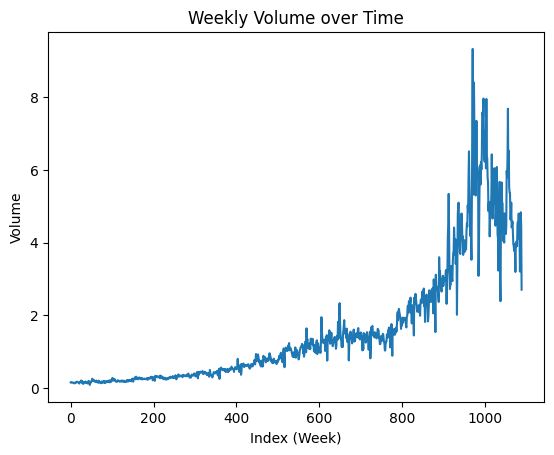

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

num_cols = ['Year','Lag1','Lag2','Lag3','Lag4','Lag5','Volume','Today']
print(weekly[num_cols].corr())

plt.figure()
plt.plot(weekly['Volume'].values)
plt.title('Weekly Volume over Time')
plt.xlabel('Index (Week)')
plt.ylabel('Volume')
plt.show()


(b) Use the full data set to perform a logistic regression with
Direction as the response and the five lag variables plus Volume
as predictors. Use the summary function to print the results. Do
any of the predictors appear to be statistically significant? If so,
which ones?


In [13]:
import pandas as pd
import statsmodels.api as sm
weekly = load_data('Weekly')
weekly.head()

weekly['Direction_bin'] = (weekly['Direction'] == 'Up').astype(int)

X = weekly[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
X = sm.add_constant(X)
y = weekly['Direction_bin']

model = sm.Logit(y, X)
result = model.fit()
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:          Direction_bin   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Sun, 02 Nov 2025   Pseudo R-squ.:                0.006580
Time:                        09:40:00   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

(c) Compute the confusion matrix and overall fraction of correct
predictions. Explain what the confusion matrix is telling you
about the types of mistakes made by logistic regression.


In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_prob = result.predict(X)

y_pred = (y_prob > 0.5).astype(int)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print("confusion matrix：\n", cm)
print(f"\noverall fraction of correct predictions：{acc:.4f}")


confusion matrix：
 [[ 54 430]
 [ 48 557]]

overall fraction of correct predictions：0.5611


Logistic regression models tend to predict market uptrends. Because most samples actually show an "up" trend, the model learns a pattern biased towards "up." Therefore, it has high accuracy in predicting uptrends but poor performance in predicting downtrends. This indicates that the model is not good at identifying "down weeks" (low recall for downtrends).

(d) Now fit the logistic regression model using a training data period
from 1990 to 2008, with Lag2 as the only predictor. Compute the
confusion matrix and the overall fraction of correct predictions
for the held out data (that is, the data from 2009 and 2010).

In [21]:
weekly = load_data('Weekly')
weekly['Direction_bin'] = (weekly['Direction'] == 'Up').astype(int)

train = weekly['Year'] < 2009
test = ~train

X_train = sm.add_constant(weekly.loc[train, ['Lag2']])
y_train = weekly.loc[train, 'Direction_bin']
X_test = sm.add_constant(weekly.loc[test, ['Lag2']])
y_test = weekly.loc[test, 'Direction_bin']
model = sm.Logit(y_train, X_train)
result = model.fit()
print(result.summary())

y_prob = result.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print("confusion matrix：\n", cm)
print(f"\noverall fraction of correct predictions：{acc:.4f}")


Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:          Direction_bin   No. Observations:                  985
Model:                          Logit   Df Residuals:                      983
Method:                           MLE   Df Model:                            1
Date:                Sun, 02 Nov 2025   Pseudo R-squ.:                0.003076
Time:                        09:57:43   Log-Likelihood:                -675.27
converged:                       True   LL-Null:                       -677.35
Covariance Type:            nonrobust   LLR p-value:                   0.04123
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2033      0.064      3.162      0.002       0.077       0.329
Lag2           0.0581      0.